In [34]:

import pandas as pd
import numpy as np
from IPython.display import display

In [35]:
# Load the CSV
ufcfights = pd.read_csv("newufcfights.csv")

# Sort with the most recent at the bottom (CSV is newest-first, so descending index = oldest first)
ufcfights = ufcfights.sort_index(ascending=False)

unique_events = ufcfights[['event']].drop_duplicates().reset_index(drop=True)
unique_events['event_id'] = range(1, len(unique_events) + 1)
ufcfights = ufcfights.merge(unique_events, on='event')
ufcfights['method'] = ufcfights['method'].apply(lambda x: 'KO' if 'KO' in x else ('SUB' if 'SUB' in x else x))
ufcfights['result'] = ufcfights['result'].apply(lambda x: 'nc' if 'nc' in x else ('draw' if 'draw' in x else x))
# Drop unnecessary columns
ufcfights.drop(columns=["weight","round", "time"], inplace=True)
print(ufcfights.head())


                  event       fighter_1      fighter_2 result method  event_id
0  UFC 1: The Beginning  Gerard Gordeau     Teila Tuli    win     KO         1
1  UFC 1: The Beginning    Kevin Rosier   Zane Frazier    win     KO         1
2  UFC 1: The Beginning    Royce Gracie  Art Jimmerson    win    SUB         1
3  UFC 1: The Beginning    Ken Shamrock  Patrick Smith    win    SUB         1
4  UFC 1: The Beginning  Gerard Gordeau   Kevin Rosier    win     KO         1


In [36]:
# Initialize Elo ratings
initial_elo = 1000 
elo_ratings = {}
base_k_factor = 40 # up to 200 as fighters have matches at least 5x rarelier than in chess - for better comparison

In [37]:


# Function to calculate the expected score
def expected_score(elo_a, elo_b):
    return 1 / (1 + 10**((elo_b - elo_a) / 400))

# Function to update Elo ratings
def update_elo(winner_elo, loser_elo, k_factor, result="win"):
    expected_win = expected_score(winner_elo, loser_elo)
    if result == "win":  # Winner-loser case
        new_winner_elo = winner_elo + k_factor * (1 - expected_win)
        new_loser_elo = loser_elo + k_factor * (0 - (1 - expected_win))
    elif result == "draw":  # Draw case
        new_winner_elo = winner_elo + k_factor * (0.5 - expected_win)
        new_loser_elo = loser_elo + k_factor * (0.5 - (1 - expected_win))
    else:  # No contest, no Elo change
        new_winner_elo, new_loser_elo = winner_elo, loser_elo
    return round(new_winner_elo, 2), round(new_loser_elo, 2)

def get_k_factor(method, base_k=40):
    if method == 'KO' or method == 'SUB':
        return base_k * 1.15  # Increase K by 15% for KO or submission
    else:
        return base_k  # Default to base K for other outcomes

In [38]:
ufcfights['cc_match'] = np.arange(1, len(ufcfights) + 1)

# Add columns for Elo ratings
ufcfights['fighter_1_elo_start'] = 0.0
ufcfights['fighter_2_elo_start'] = 0.0
ufcfights['fighter_1_elo_end'] = 0.0
ufcfights['fighter_2_elo_end'] = 0.0

# Calculate Elo ratings for each match
for index, row in ufcfights.iterrows():
    fighter_1 = row['fighter_1']
    fighter_2 = row['fighter_2']

    # Initialize Elo ratings if fighters are encountered for the first time
    if fighter_1 not in elo_ratings:
        elo_ratings[fighter_1] = initial_elo
    if fighter_2 not in elo_ratings:
        elo_ratings[fighter_2] = initial_elo


    # Get starting Elo ratings
    fighter_1_elo_start = elo_ratings[fighter_1]
    fighter_2_elo_start = elo_ratings[fighter_2]

    #kfactor adjust
    fight_method = row["method"]
    current_k = get_k_factor(fight_method,base_k_factor)


    # Record starting Elo ratings
    ufcfights.at[index, 'fighter_1_elo_start'] = fighter_1_elo_start
    ufcfights.at[index, 'fighter_2_elo_start'] = fighter_2_elo_start

    # Update Elo based on the result
    if row['result'] == 'win':  # Fighter 1 wins
        new_fighter1_elo, new_fighter2_elo = update_elo(fighter_1_elo_start, fighter_2_elo_start, current_k)
    elif row['result'] == 'draw':  # Draw
        new_fighter1_elo, new_fighter2_elo = update_elo(fighter_1_elo_start, fighter_2_elo_start, current_k,result="draw")
    else:  # No contest
        new_fighter1_elo, new_fighter2_elo = fighter_1_elo_start, fighter_2_elo_start

    # Record updated Elo ratings
    ufcfights.at[index, 'fighter_1_elo_end'] = new_fighter1_elo
    ufcfights.at[index, 'fighter_2_elo_end'] = new_fighter2_elo

    # Update Elo ratings in the dictionary
    elo_ratings[fighter_1] = new_fighter1_elo
    elo_ratings[fighter_2] = new_fighter2_elo

# ------------------------------

In [39]:
def get_fighter_info(fighter_name, elo_ratings, ufcfights, initial_elo=1000):
    import matplotlib.pyplot as plt
    import pandas as pd

    # Check if the fighter exists in the Elo ratings dictionary
    if fighter_name not in elo_ratings:
        print(f"Initializing Elo for {fighter_name} at {initial_elo}")
        elo_ratings[fighter_name] = initial_elo

    # Fights where the fighter is listed as fighter_1
    fighter_matches_1 = ufcfights[ufcfights['fighter_1'] == fighter_name][
        ['event', 'fighter_2', 'result', 'event_id',
         'fighter_1_elo_start', 'fighter_1_elo_end',]
         #'age_A', 'age_B']
    ].rename(columns={
        'fighter_2': 'opponent',
        'fighter_1_elo_start': 'own elo start',
        'fighter_1_elo_end': 'own elo end',
        'age_A': 'own_age',
        #'age_B': 'opponent_age'
    })

    # Fights where the fighter is listed as fighter_2
    fighter_matches_2 = ufcfights[ufcfights['fighter_2'] == fighter_name][
        ['event', 'fighter_1', 'result', 'event_id',
         'fighter_2_elo_start', 'fighter_2_elo_end',]
         #'age_B', 'age_A']
    ].rename(columns={
        'fighter_1': 'opponent',
        'fighter_2_elo_start': 'own elo start',
        'fighter_2_elo_end': 'own elo end',
        #'age_B': 'own_age',
        #'age_A': 'opponent_age'
    })

    # Adjust result for when the fighter was the second fighter
    fighter_matches_2['result'] = fighter_matches_2['result'].str.replace('win', 'loss')

    # Combine and sort matches by event_id
    fighter_matches = pd.concat([fighter_matches_1, fighter_matches_2]).reset_index(drop=True)
    fighter_matches = fighter_matches.sort_values(by='event_id')

    # Add a fight number column (1, 2, 3, ...)
    fighter_matches['fight_number'] = range(1, len(fighter_matches) + 1)

    # Check if there are any matches for the fighter
    if fighter_matches.empty:
        print(f"{fighter_name} has no recorded matches.")
        return

    # Display the Elo ratings and match details
    print(f"{fighter_name}'s current Elo rating: {elo_ratings[fighter_name]}")
    print(f"{fighter_name}'s matches:")
    display(fighter_matches)

    # Plot Elo progression over the fighter's career
    plt.figure(figsize=(10, 6))
    plt.plot(
        fighter_matches['fight_number'],
        fighter_matches['own elo end'],
        marker='o',
        label='Elo Rating'
    )
    plt.title(f"{fighter_name}'s Elo Rating Progression")
    plt.xlabel("Fight Number")
    plt.ylabel("Elo Rating")
    plt.grid(True)
    plt.xticks(range(1, len(fighter_matches) + 1))  # Ensure x-axis labels are integers
    plt.legend()
    plt.show()

Sean Strickland's current Elo rating: 1196.35
Sean Strickland's matches:


,event,opponent,result,event_id,own elo start,own elo end,fight_number
0,UFC 171: Hendricks vs Lawler,Robert McDaniel,win,266,1000.00,1023.38,1
1,UFC Fight Night: Munoz vs Mousasi,Luke Barnatt,win,274,1023.38,1045.75,2
18,UFC Fight Night: Bigfoot vs Mir,Santiago Ponzinibbio,loss,309,1045.75,1023.44,3
2,UFC Fight Night: Mir vs Duffee,Igor Araujo,win,327,1023.44,1043.05,4
3,UFC Fight Night: Cowboy vs Cowboy,Alex Garcia,win,349,1043.05,1066.27,5
4,UFC 199: Rockhold vs. Bisping 2,Tom Breese,win,359,1066.27,1086.05,6
19,UFC 210: Cormier vs. Johnson 2,Kamaru Usman,loss,394,1086.05,1065.82,7
5,UFC Fight Night: Poirier vs. Pettis,Court McGee,win,417,1065.82,1083.45,8
20,UFC 224: Nunes vs. Pennington,Elizeu Zaleski dos Santos,loss,437,1083.45,1059.05,9
6,UFC Fight Night: Oezdemir vs. Smith,Nordine Taleb,win,454,1059.05,1081.65,10


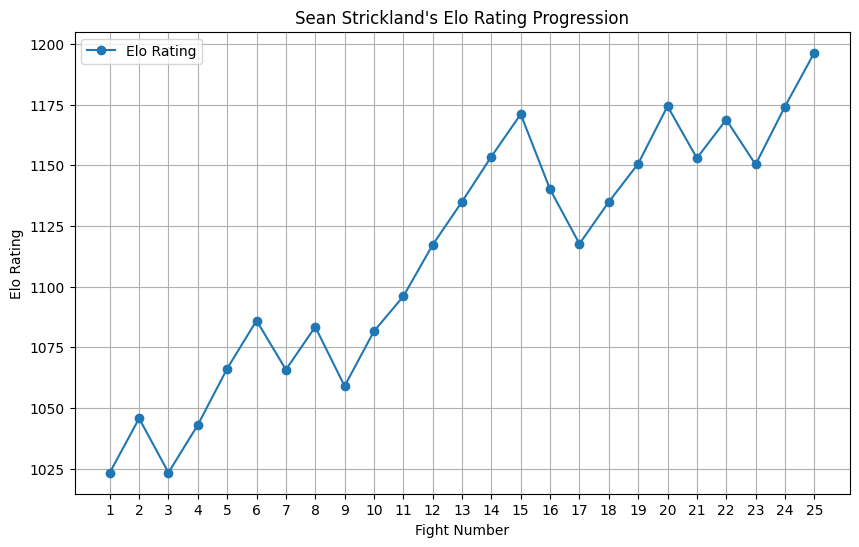

In [40]:
get_fighter_info("Sean Strickland", elo_ratings, ufcfights)

In [41]:
import matplotlib.pyplot as plt

if 'age_A' not in ufcfights.columns or 'age_B' not in ufcfights.columns:
    print("Skipping Elo vs Age plot: age_A / age_B columns not present in dataset.")
else:
    # Build one row per fighter per fight: fighter, age at fight, Elo at end of fight
    fighter1_points = ufcfights[['fighter_1', 'age_A', 'fighter_1_elo_end']].copy()
    fighter1_points.columns = ['fighter', 'age', 'elo']

    fighter2_points = ufcfights[['fighter_2', 'age_B', 'fighter_2_elo_end']].copy()
    fighter2_points.columns = ['fighter', 'age', 'elo']

    # Stack them together -> TWO points per fight (one per fighter)
    elo_age = pd.concat([fighter1_points, fighter2_points], ignore_index=True)

    # Drop any point where age or elo is NA
    elo_age = elo_age.dropna(subset=['age', 'elo'])

    min_age = int(elo_age['age'].min())
    max_age = int(elo_age['age'].max())

    plt.figure(figsize=(10, 6))
    plt.scatter(elo_age['age'], elo_age['elo'], s=8, alpha=0.25)
    plt.xlim(min_age - 0.5, max_age + 0.5)
    plt.xticks(np.arange(min_age, max_age + 1, 1))
    plt.xlabel("Age at Fight")
    plt.ylabel("Elo Rating (end of fight)")
    plt.title("Elo vs Age")
    plt.grid(True)
    plt.legend()
    plt.show()


Skipping Elo vs Age plot: age_A / age_B columns not present in dataset.


In [42]:
if 'elo_age' not in dir():
    print("Skipping age summary: elo_age not available (age columns missing).")
else:
    age_summary = (
        elo_age
        .groupby('age')['elo']
        .agg(count='size', mean_elo='mean', median_elo='median')
        .reset_index()
    )

    min_count = 500
    age_summary_good = age_summary[age_summary['count'] >= min_count]

    print(age_summary_good[['age', 'count']])

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    plt.plot(age_summary_good['age'], age_summary_good['mean_elo'], marker='o')
    plt.xlabel("Age")
    plt.ylabel("Mean Elo (end of fight)")
    plt.title(f"Mean Elo by Age (only ages with ≥{min_count} fighter-fights)")
    plt.grid(True)
    plt.show()


Skipping age summary: elo_age not available (age columns missing).


In [43]:
if 'elo_age' not in dir():
    print("Skipping fights-by-age histogram: elo_age not available (age columns missing).")
else:
    plt.figure(figsize=(10, 4))
    plt.hist(elo_age['age'], bins=range(int(elo_age['age'].min()), int(elo_age['age'].max()) + 2))
    plt.xlabel("Age")
    plt.ylabel("Number of fighter-fights")
    plt.title("Number of Fights by Age")
    plt.grid(True)
    plt.show()


Skipping fights-by-age histogram: elo_age not available (age columns missing).


In [44]:
if 'age_A' not in ufcfights.columns or 'age_B' not in ufcfights.columns:
    print("Skipping Elo delta by age: age_A / age_B columns not present in dataset.")
else:
    f1 = ufcfights[['age_A', 'fighter_1_elo_start', 'fighter_1_elo_end']].copy()
    f1['delta'] = f1['fighter_1_elo_end'] - f1['fighter_1_elo_start']
    f1.rename(columns={'age_A': 'age'}, inplace=True)

    f2 = ufcfights[['age_B', 'fighter_2_elo_start', 'fighter_2_elo_end']].copy()
    f2['delta'] = f2['fighter_2_elo_end'] - f2['fighter_2_elo_start']
    f2.rename(columns={'age_B': 'age'}, inplace=True)

    elo_delta = pd.concat([f1[['age', 'delta']], f2[['age', 'delta']]], ignore_index=True)
    elo_delta = elo_delta.dropna(subset=['age', 'delta'])

    delta_summary = (
        elo_delta
        .groupby('age')['delta']
        .agg(mean_delta='mean', count='size')
        .reset_index()
    )

    min_count = 200
    delta_summary_good = delta_summary[delta_summary['count'] >= min_count]

    plt.figure(figsize=(10, 6))
    plt.axhline(0, linewidth=1)
    plt.plot(delta_summary_good['age'], delta_summary_good['mean_delta'], marker='o')
    plt.xlabel("Age")
    plt.ylabel("Average Elo Change per Fight")
    plt.title(f"Average Elo Gain/Loss by Age (ages with ≥{min_count} fighter-fights)")
    plt.grid(True)
    plt.show()


Skipping Elo delta by age: age_A / age_B columns not present in dataset.


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'age_A' not in ufcfights.columns or 'age_B' not in ufcfights.columns:
    print("Skipping older vs younger analysis: age_A / age_B columns not present in dataset.")
else:
    decisive = ufcfights[ufcfights['result'] == 'win'].copy()
    decisive = decisive.dropna(subset=['age_A', 'age_B'])

    decisive['age_diff'] = decisive['age_A'] - decisive['age_B']
    decisive['abs_age_diff'] = decisive['age_diff'].abs()
    decisive['winner_is_older'] = (decisive['age_diff'] > 0).astype(int)

    bins   = [0, 1, 2, 3, 5, 10, 20, 999]
    labels = ['0–1', '1–2', '2–3', '3–5', '5–10', '10–20', '20+']

    decisive['age_diff_bin'] = pd.cut(
        decisive['abs_age_diff'], bins=bins, labels=labels,
        include_lowest=True, right=False
    )

    age_diff_summary = (
        decisive
        .groupby('age_diff_bin')['winner_is_older']
        .agg(win_rate='mean', count='size')
        .reset_index()
    )

    print(age_diff_summary)

    plt.figure(figsize=(10, 6))
    plt.axhline(0.5, linestyle='--', linewidth=1)
    plt.plot(age_diff_summary['age_diff_bin'].astype(str), age_diff_summary['win_rate'], marker='o')
    plt.xlabel("Absolute Age Difference (years)")
    plt.ylabel("P(Older Fighter Wins)")
    plt.title("Older vs Younger: Win Rate by Age Gap")
    plt.grid(True)
    plt.show()


Skipping older vs younger analysis: age_A / age_B columns not present in dataset.
